#You should compile the data into **two dataframes**:

- **one with visitor data (one row for each date)**  

- one with **summary data (one row for each venue)**

**compiled from all the .csv files**, including the visitor data.

Remember: You can explore many visualisation in the notebook but you can only show maximum 8, which are useful, in the report.

**For introduction, remember to explain what data visualisation is to the company.**

For notebook: Markdown sections should **indicate the purpose of each code section** (**don't need to describe piece of code line by line, more a minimal thing, describing "this is a scatterplot used to see the relationships between two variables"**), but you do not have to present your findings in
the notebook.

**At least 2 of the visualisations in the notebook** should be interactive and provide functionality to explore the
data in more detail. The markdown for these must include a description of available user interactions and
instructions on how to use the interactions to explore the data more fully.

#Data:

• https://tinyurl.com/ChrisCoDV/001357669/VenueDailyVisitors.csv

**listing the daily number of visitors to the company's 35 venues**

• https://tinyurl.com/ChrisCoDV/001357669/VenueAge.csv

the **average age** of visitors at each venue

• https://tinyurl.com/ChrisCoDV/001357669/VenueDistance.csv

the maximum distance (**miles**) that visitors have travelled to each venue

• https://tinyurl.com/ChrisCoDV/001357669/VenueDuration.csv

the average time (**mins**) that visitors spend at each venue

• https://tinyurl.com/ChrisCoDV/001357669/VenueGender.csv
the percentage of visitors identifying as female at each venue

• https://tinyurl.com/ChrisCoDV/001357669/VenueSpend.csv

the average spend (**£**) by visitors at each venue


#Visitor Data

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

data = pd.read_csv('https://tinyurl.com/ChrisCoDV/001357669/VenueDailyVisitors.csv', index_col=0)
data.index = pd.to_datetime(data.index)
print(data.head())

            DAT  ZOZ  TNB  MAJ  CUB  RNT  AOJ  UAF  RTE  VIY  ...  NSY  NMN  \
Date                                                          ...             
2023-01-01   83   97    0  249   87    0   79    0   77  222  ...  287  463   
2023-01-02  107   66    0  197   53    0   78    0   64  178  ...  274  598   
2023-01-03   85   80    0  223   59    0   70    0   70  212  ...  195  474   
2023-01-04   88   88    0  178   54    0   83    0   84  148  ...  157  419   
2023-01-05   89  115    0   70   87    0   84    0   85   82  ...  192  420   

            OSG  WAN  DGG  QHZ  UHQ  BAL  VUV  OAQ  
Date                                                
2023-01-01  566  184   48   89    0   72    0  489  
2023-01-02  492  175   72   85    0   66    0  486  
2023-01-03  422  139   67   81    0   60    0  392  
2023-01-04  370   86   65   69    0   63    0  300  
2023-01-05  376  109   61   82    0   65    0  332  

[5 rows x 35 columns]


I can see that some venues were shut in January 2023.

In [ ]:
!pip install hvplot
import holoviews as hv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.4/175.4 kB 5.0 MB/s eta 0:00:00


In [ ]:
import hvplot.pandas

In [ ]:
print(data.tail())

            DAT  ZOZ  TNB  MAJ  CUB  RNT  AOJ  UAF  RTE  VIY  ...  NSY  NMN  \
Date                                                          ...             
2023-12-27   72  105  259  215   57   87   87  111   89  128  ...  197  397   
2023-12-28   88   71   63  136   59   47   88   26   73  126  ...  153  448   
2023-12-29   81   85  121  147   95   19   83  132   77  142  ...  260  468   
2023-12-30   88   58    0  275   77   14   77   57   80  204  ...  241  583   
2023-12-31  112   99   28  212   53   57   80   84   82  207  ...  306  718   

            OSG  WAN  DGG  QHZ  UHQ  BAL  VUV  OAQ  
Date                                                
2023-12-27  373  101   59   87  129   66  231  364  
2023-12-28  380  112   67   69   79   61  132  350  
2023-12-29  451  146   72   75    0   60  146  413  
2023-12-30  545  178   74   74   13   64   30  469  
2023-12-31  572  246   66   75  136   67  126  512  

[5 rows x 35 columns]


In [ ]:
data.shape

(365, 35)

There are 365 days and 35 venues with daily visitor data.

##Top 5 venues visited: NMN, NGD, OSG, OAQ, MGT
Sorting daily vistors data from largest to smallest.


In [ ]:
data = data.reindex(data.mean().sort_values(ascending=False).index, axis=1)
(data.sum().head(5))


,0
NMN,174537
NGD,172851
OSG,171265
OAQ,154713
MGT,97704


In [ ]:
(data.sum().head(15))


,0
NMN,174537
NGD,172851
OSG,171265
OAQ,154713
MGT,97704
LME,83691
NSY,83468
MAJ,74843
VIY,63873
WUC,55724


In [ ]:
# Save to CSV (optional)
data.to_csv("Visitor_Data.csv", index=False)

#Creating Summary Data

Summary Data

In [ ]:
#daily_visitors = pd.read_csv('https://tinyurl.com/ChrisCoDV/001357669/VenueDailyVisitors.csv', index_col=0)
#needs to be a sum to make annual visitors and merge it
data = pd.read_csv('https://tinyurl.com/ChrisCoDV/001357669/VenueDailyVisitors.csv', index_col=0)
data.index = pd.to_datetime(data.index)

venue_duration = pd.read_csv('https://tinyurl.com/ChrisCoDV/001357669/VenueDuration.csv', index_col=0)

annual_visitors = data.sum()

venue_spend = pd.read_csv('https://tinyurl.com/ChrisCoDV/001357669/VenueSpend.csv', index_col=0)

venue_age = pd.read_csv('https://tinyurl.com/ChrisCoDV/001357669/VenueAge.csv', index_col=0)

venue_female = pd.read_csv('https://tinyurl.com/ChrisCoDV/001357669/VenueGender.csv', index_col=0)

venue_distance = pd.read_csv('https://tinyurl.com/ChrisCoDV/001357669/VenueDistance.csv', index_col=0)




In [ ]:
annual_visitors

,0
DAT,32105
ZOZ,32282
TNB,12039
MAJ,74843
CUB,25373
RNT,10123
AOJ,29013
UAF,4366
RTE,29058
VIY,63873


In [ ]:
summary_data = pd.DataFrame(index=data.columns)

summary_data['Average Duration'] = venue_duration.values # unit mins, average time spent at venue
summary_data['Annual Visitors'] = annual_visitors.values #unit vistors
summary_data['Average Spend'] = venue_spend.values # unit £
summary_data['Average Age'] = venue_age.values # unit
summary_data['Female %'] = venue_female.values # unit %
summary_data['Maximum Distance'] = venue_distance.values # unit miles



# print(summary_data.head())
# print(summary_data.describe())
summary_data
# summary_data.describe()

,Average Duration,Annual Visitors,Average Spend,Average Age,Female %,Maximum Distance
DAT,103,32105,22,29,42,14
ZOZ,108,32282,24,48,48,11
TNB,99,12039,13,36,54,2
MAJ,78,74843,21,46,53,15
CUB,150,25373,12,28,59,6
RNT,118,10123,14,25,47,4
AOJ,103,29013,24,43,48,8
UAF,66,4366,18,29,41,1
RTE,109,29058,16,37,45,10
VIY,120,63873,29,48,51,26


In [ ]:
summary_data.shape

(35, 6)

35 venues and 6 columns of data

In [ ]:
# Save to CSV (optional)
summary_data.to_csv("summary_data.csv", index=False)

#**Visitor Data Visualisations**

#Finding High, Medium, Low (and very low) Volume Venues

High Volume: ['NMN', 'NGD', 'OSG', 'OAQ']
Medium Volume: ['MGT', 'LME', 'NSY', 'MAJ', 'VIY', 'WUC', 'VOK', 'WAN']
Low Volume: ['EUI', 'ZOZ', 'DAT', 'BGW', 'QHZ']
Very Low Volume: ['AUT', 'QNM', 'RTE', 'AOJ', 'CUB', 'RBO', 'DGG', 'ZGP', 'COQ', 'BAL', 'VUV', 'SZY', 'TNB', 'TTL', 'RNT', 'SHI', 'UHQ', 'UAF']


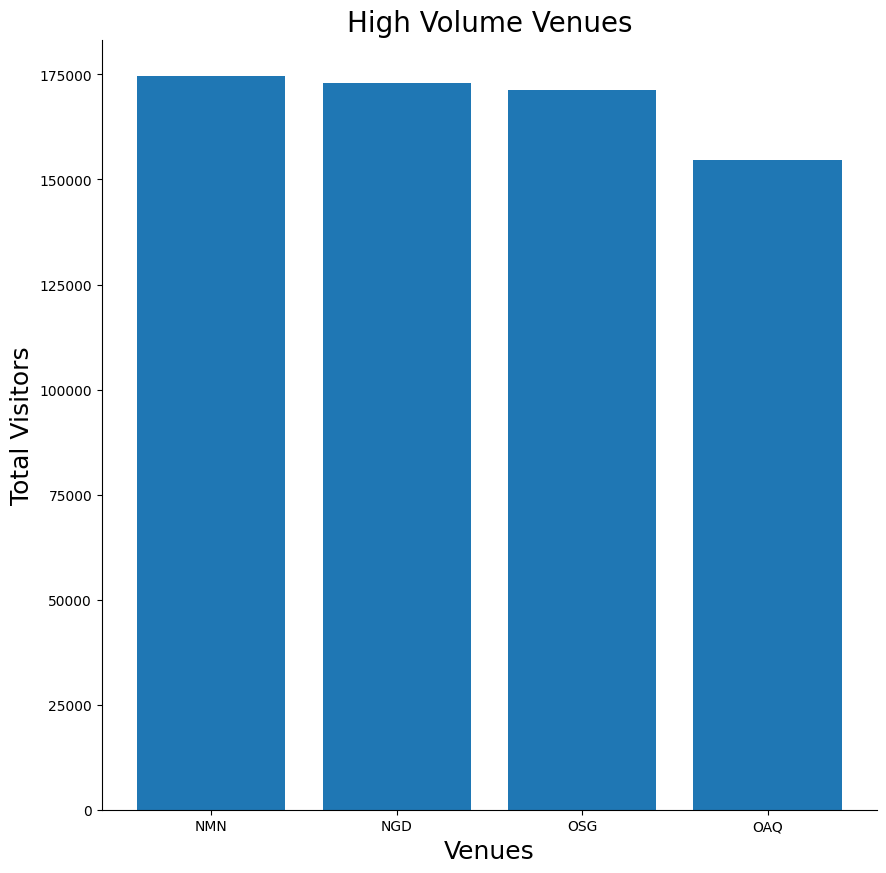

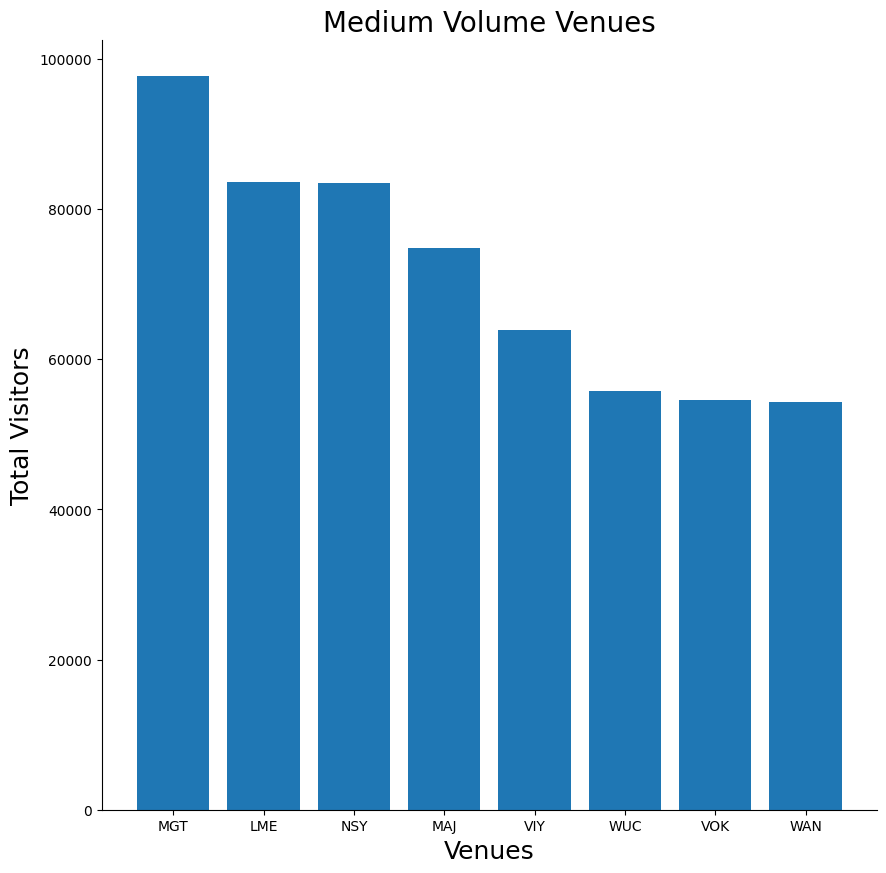

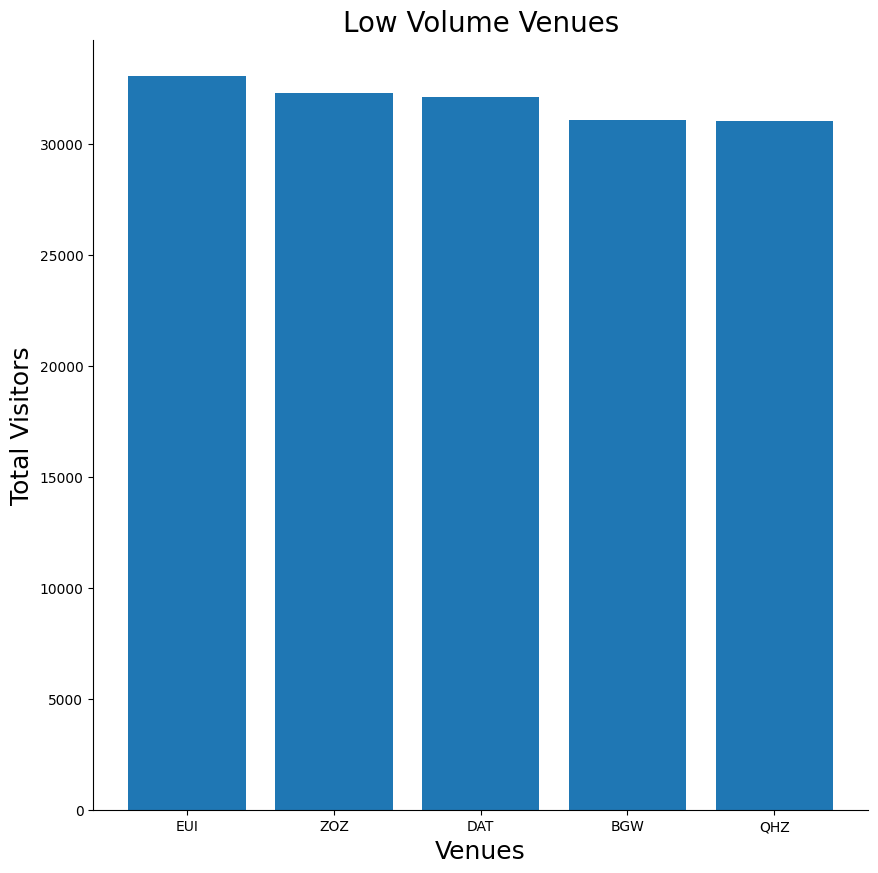

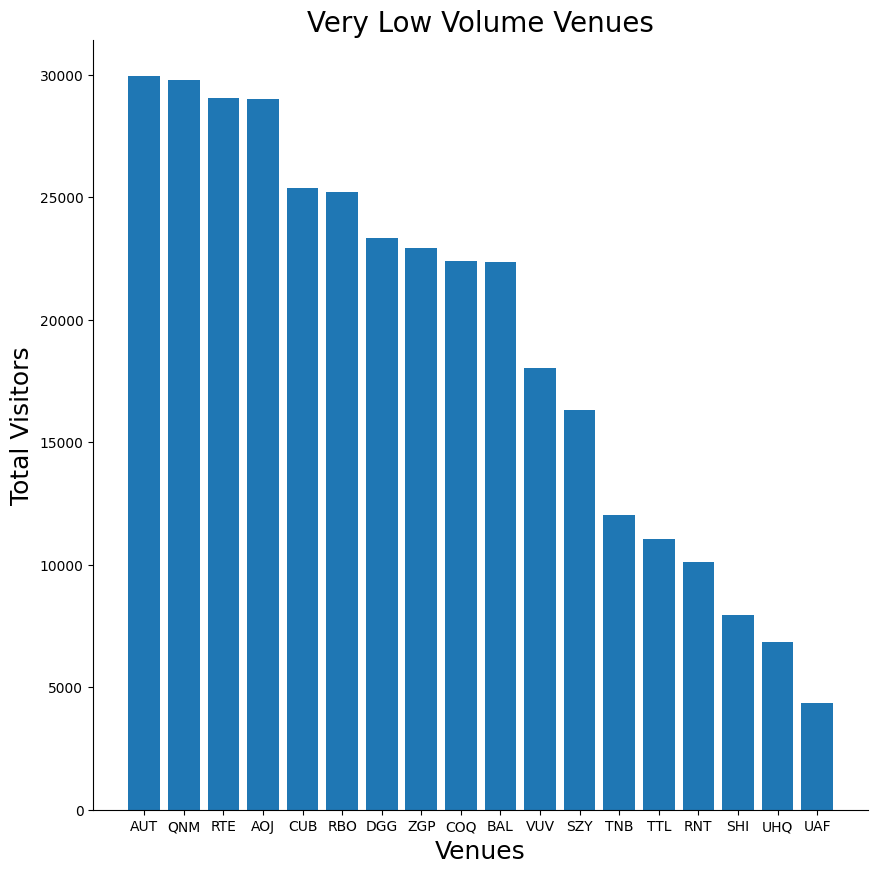

In [ ]:
data = data.reindex(data.sum().sort_values(ascending=False).index, axis=1)
segment_limits = {  # lower limits for each segment (must be in ascending order!)
    0: 'Very Low Volume',
    30_000: 'Low Volume',
    50_000: 'Medium Volume',
    150_000: 'High Volume',
}
segments = {}
limits = list(segment_limits.keys())

for i in range(len(limits)):
    if i < len(limits) - 1:
        included = (limits[i] <= data.sum()) & (data.sum() < limits[i + 1])  # the round brackets are important
    else:
        included = (limits[i] <= data.sum())  # the round brackets are important
    segment_name = segment_limits[limits[i]]
    segment_columns = data.columns[included]
    segments[segment_name] = list(segment_columns)

for segment_name in reversed(segments):
    print(f'{segment_name}: {segments[segment_name]}')

for segment_name in reversed(segments):
    selected = segments[segment_name]
    plt.figure(figsize=(10, 10))
    x_pos = np.arange(len(data[selected].columns))
    plt.bar(x_pos, data[selected].sum(), align='center')
    plt.xticks(x_pos, data[selected].columns)
    plt.xlabel('Venues', fontsize=18)
    plt.ylabel('Total Visitors', fontsize=18)
    plt.title(segment_name + ' Venues', fontsize=20)

    for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
      if spine.spine_type != 'bottom' and spine.spine_type != 'left':
        spine.set_visible(False)

    plt.show()

**The most visited venues are NMN, NGD, OSG and OAQ**.

High Volume: ['NMN', 'NGD', 'OSG', 'OAQ']

Medium Volume: ['MGT', 'LME', 'NSY', 'MAJ', 'VIY', 'WUC', 'VOK', 'WAN']

Low Volume: ['EUI', 'ZOZ', 'DAT', 'BGW', 'QHZ']

Very Low Volume: ['AUT', 'QNM', 'RTE', 'AOJ', 'CUB', 'RBO', 'DGG', 'ZGP', 'COQ', 'BAL', 'VUV', 'SZY', 'TNB', 'TTL', 'RNT', 'SHI', 'UHQ', 'UAF']

#Line Plot for total visitors - timeseries

In [ ]:
data

,NMN,NGD,OSG,OAQ,MGT,LME,NSY,MAJ,VIY,WUC,...,COQ,BAL,VUV,SZY,TNB,TTL,RNT,SHI,UHQ,UAF
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-01,463,460,566,489,316,292,287,249,222,180,...,56,72,0,96,0,66,0,0,0,0
2023-01-02,598,500,492,486,296,248,274,197,178,199,...,68,66,0,92,0,54,0,0,0,0
2023-01-03,474,452,422,392,238,202,195,223,212,116,...,69,60,0,91,0,63,0,0,0,0
2023-01-04,419,328,370,300,236,204,157,178,148,122,...,59,63,0,92,0,88,0,0,0,0
2023-01-05,420,294,376,332,204,218,192,70,82,89,...,58,65,0,88,0,54,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,397,249,373,364,223,185,197,215,128,105,...,69,66,231,0,259,0,87,64,129,111
2023-12-28,448,431,380,350,262,198,153,136,126,112,...,70,61,132,0,63,0,47,100,79,26
2023-12-29,468,657,451,413,276,183,260,147,142,156,...,44,60,146,0,121,0,19,127,0,132


In [ ]:
total = data.sum(axis=1)
#axis = 1 makes sum of rows

In [ ]:
total

,0
Date,
2023-01-01,5201
2023-01-02,5115
2023-01-03,4438
2023-01-04,3991
2023-01-05,3815
...,...
2023-12-27,4668
2023-12-28,4361
2023-12-29,5201


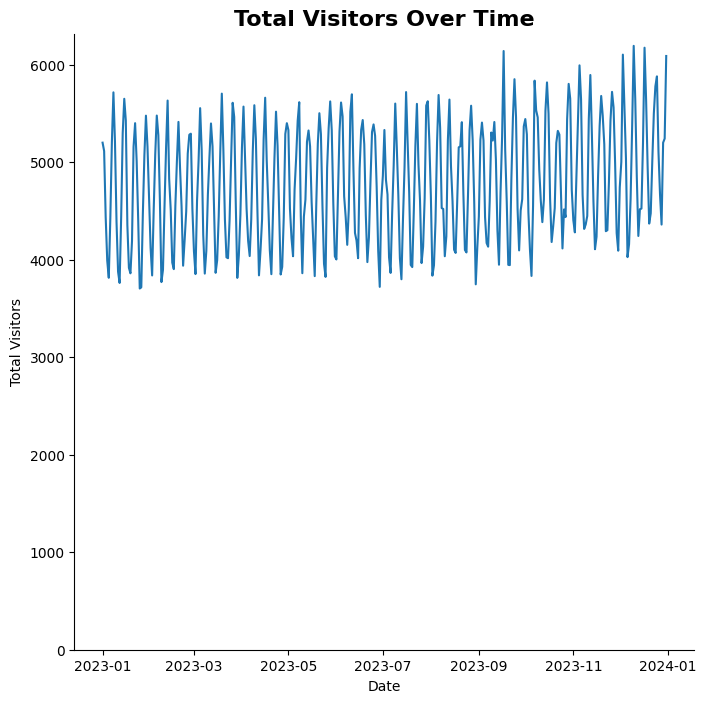

In [ ]:
plt.figure(figsize=(8, 8))
plt.plot(total)
plt.ylim(0)
plt.xlabel('Date')
plt.ylabel('Total Visitors')
plt.title('Total Visitors Over Time', fontsize=16, fontweight='bold')

for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
  if spine.spine_type != 'bottom' and spine.spine_type != 'left':
    spine.set_visible(False)

plt.show()

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
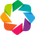

:Curve   [Date]   (0)

In [ ]:
plot = total.hvplot.line(
    frame_height=750, frame_width=750,
    xlabel='Date', ylabel='Total Visitors',
    title='Total Visitors Over Time'
)
hv.extension('bokeh')
plot

In general, the total number of visitors from all venues rises slowly from January 2023 to January 2024. December had the most visitors. The highest day of total visitors across all venues was Sunday 10th December 2023 with 6194. Sunday 17th September 2023 came in second with 6141 total visitors which was quite a big jump in relation to other days in that month.

There is seasonality, a pattern, in that the higher total number of visitors are usually on Sundays. The lower total number of visitors are usually Tuesdays to Thursdays.


**(Use snipping tool with the hover to showcase the data)**

In [ ]:
total

,0
Date,
2023-01-01,5201
2023-01-02,5115
2023-01-03,4438
2023-01-04,3991
2023-01-05,3815
...,...
2023-12-27,4668
2023-12-28,4361
2023-12-29,5201


In [ ]:
totalDec = total.loc[pd.to_datetime('2023-12-01'): pd.to_datetime('2023-12-31')]
#do stacked area plot

In [ ]:
dec = totalDec.sum()

In [ ]:
dec

np.int64(158258)

#Stacked Area Plot of Visitors

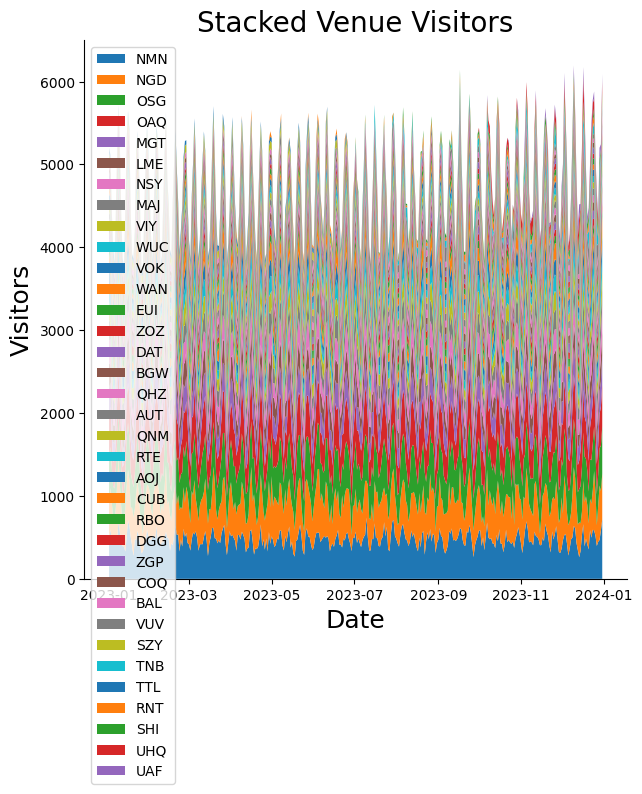

In [ ]:
plt.figure(figsize=(7, 7))
# data.plot.area(figsize=(7, 7))
plt.stackplot(data.index, data.transpose())
plt.xlabel('Date', fontsize=18)
plt.ylabel('Visitors', fontsize=18)
plt.title('Stacked Venue Visitors', fontsize=20)
plt.legend(data.columns, loc=2)

for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
  if spine.spine_type != 'bottom' and spine.spine_type != 'left':
    spine.set_visible(False)

plt.show()


#Line plots for high volume venues

            NMN  NGD  OSG  OAQ
Date                          
2023-01-01  463  460  566  489
2023-01-02  598  500  492  486
2023-01-03  474  452  422  392
2023-01-04  419  328  370  300
2023-01-05  420  294  376  332


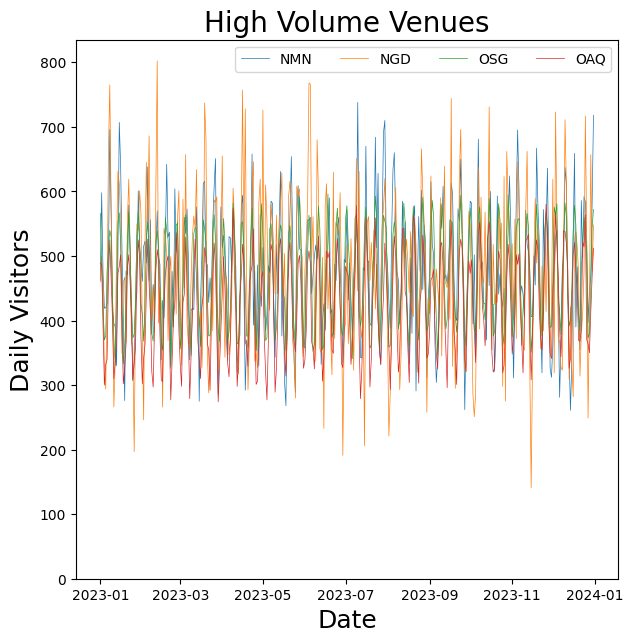

In [ ]:
selected = ['NMN', 'NGD', 'OSG', 'OAQ']
print(data[selected].head())

# data[selected].plot.line(linewidth=0.5, figsize=(7, 7))
plt.figure(figsize=(7, 7))
plt.plot(data[selected], linewidth=0.5)
plt.ylim(ymin=0)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Daily Visitors', fontsize=18)
plt.title('High Volume Venues', fontsize=20)
plt.legend(selected, loc=1, ncol=4)
plt.show()

            NMN  NGD  OSG  OAQ
Date                          
2023-01-01  463  460  566  489
2023-01-02  598  500  492  486
2023-01-03  474  452  422  392
2023-01-04  419  328  370  300
2023-01-05  420  294  376  332


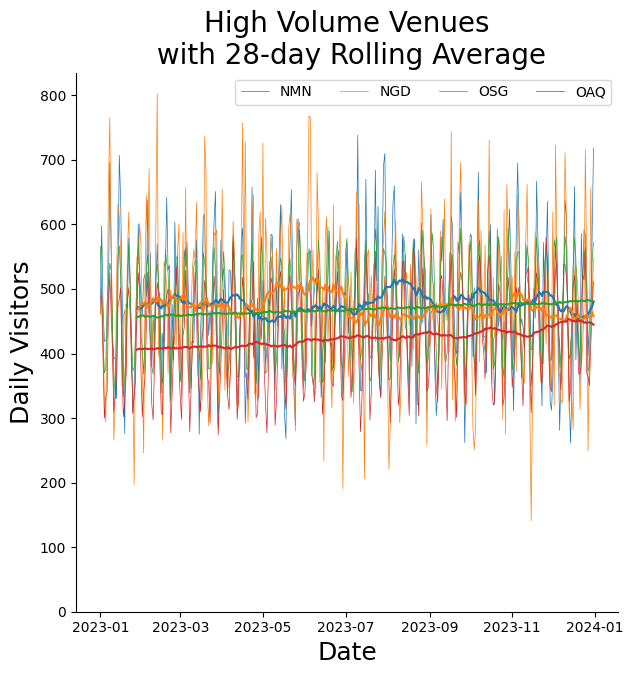

In [ ]:
period = 28
rolling_average = data.rolling(window=period).mean()

selected = ['NMN', 'NGD', 'OSG', 'OAQ']
print(data[selected].head())

plt.figure(figsize=(7, 7))
plt.plot(data[selected], linewidth=0.5)

plt.gca().set_prop_cycle(None)
plt.plot(rolling_average[selected], linewidth=1.5)
plt.ylim(ymin=0)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Daily Visitors', fontsize=18)
plt.title('High Volume Venues\n with 28-day Rolling Average', fontsize=20)
plt.legend(selected, loc=1, ncol=4)

for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
  if spine.spine_type != 'bottom' and spine.spine_type != 'left':
    spine.set_visible(False)

plt.show()

NMN (the most visited venue):
* Highest number of visitors in August 2023.

NGD (the second visited venue):

*  Number of visitors dipped in July 2023 - became the 3rd most visited among the 4 high volume venues.
*   In January 2024 (end date), it was the 3rd most visited venue.
*   NGD had the highest number of visitors in June 2023.

OSG:

* Average consistent growth in number of visitors.


OAQ (the least visited venue among high volume venues):


* The least visited among high volume venues.
* Highest number of visitors was in December 2023.
* 26th November was its highest visitor number, 580 - second most visited in that day.




In [ ]:
selected = ['OAQ']

print(data[selected].max())

OAQ    580
dtype: int64


In [ ]:
print(data[selected].tail(31))

            OAQ
Date           
2023-12-01  441
2023-12-02  492
2023-12-03  567
2023-12-04  519
2023-12-05  470
2023-12-06  387
2023-12-07  344
2023-12-08  406
2023-12-09  539
2023-12-10  538
2023-12-11  519
2023-12-12  479
2023-12-13  326
2023-12-14  341
2023-12-15  431
2023-12-16  503
2023-12-17  521
2023-12-18  480
2023-12-19  445
2023-12-20  369
2023-12-21  368
2023-12-22  386
2023-12-23  522
2023-12-24  514
2023-12-25  564
2023-12-26  370
2023-12-27  364
2023-12-28  350
2023-12-29  413
2023-12-30  469
2023-12-31  512


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
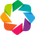

:NdOverlay   [Variable]
   :Curve   [Date]   (value)

In [ ]:
selected = ['NMN', 'NGD', 'OSG', 'OAQ']
plot = data[selected].hvplot.line(
    frame_height=500, frame_width=500,
    xlabel='Date', ylabel='Visitors',
    title='High Volume Venues'
)
hv.extension('bokeh')
plot

#Line plots medium volume visited venues

            MAJ  VIY  VOK  LME  MGT  WUC  NSY  WAN
Date                                              
2023-01-01  249  222  214  292  316  180  287  184
2023-01-02  197  178  181  248  296  199  274  175
2023-01-03  223  212  136  202  238  116  195  139
2023-01-04  178  148  136  204  236  122  157   86
2023-01-05   70   82  113  218  204   89  192  109


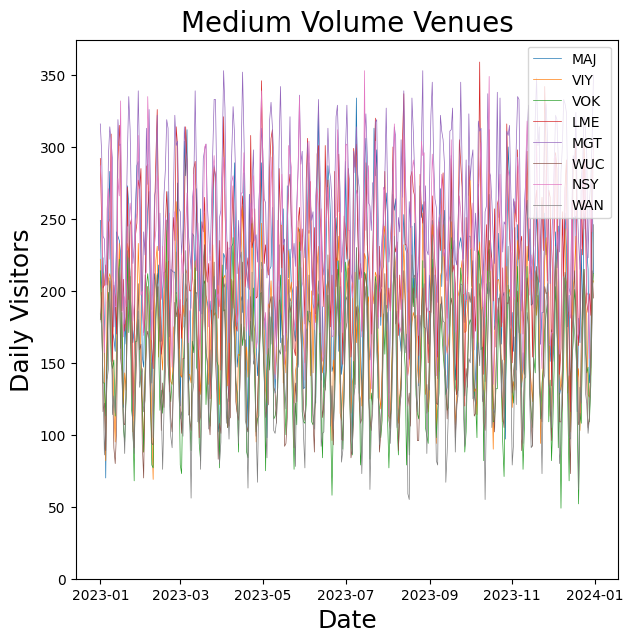

In [ ]:
selected = ['MAJ', 'VIY', 'VOK', 'LME', 'MGT', 'WUC', 'NSY', 'WAN']
print(data[selected].head())

# data[selected].plot.line(linewidth=0.5, figsize=(7, 7))
plt.figure(figsize=(7, 7))
plt.plot(data[selected], linewidth=0.5)
plt.ylim(ymin=0)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Daily Visitors', fontsize=18)
plt.title('Medium Volume Venues', fontsize=20)
plt.legend(selected, loc=1)
plt.show()

            MAJ  VIY  VOK  LME  MGT  WUC  NSY  WAN
Date                                              
2023-01-01  249  222  214  292  316  180  287  184
2023-01-02  197  178  181  248  296  199  274  175
2023-01-03  223  212  136  202  238  116  195  139
2023-01-04  178  148  136  204  236  122  157   86
2023-01-05   70   82  113  218  204   89  192  109


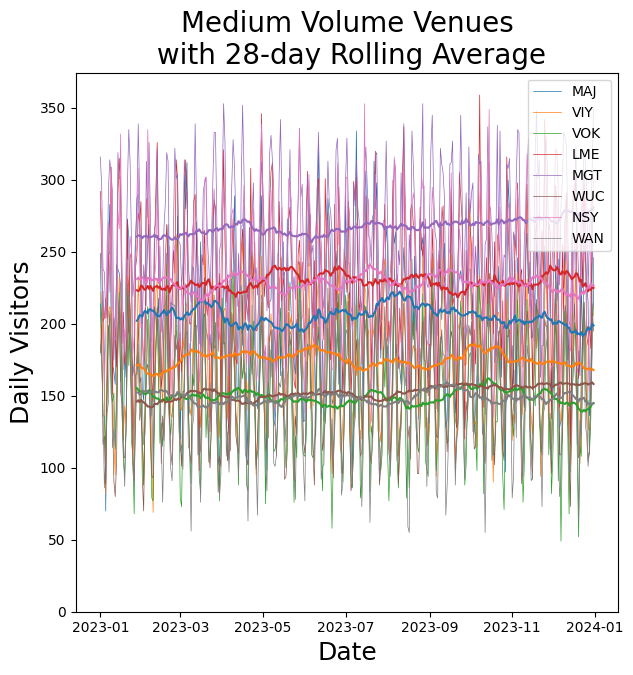

In [ ]:
period = 28
rolling_average = data.rolling(window=period).mean()

selected = ['MAJ', 'VIY', 'VOK', 'LME', 'MGT', 'WUC', 'NSY', 'WAN']
print(data[selected].head())

plt.figure(figsize=(7, 7))
plt.plot(data[selected], linewidth=0.5)

plt.gca().set_prop_cycle(None)
plt.plot(rolling_average[selected], linewidth=1.5)
plt.ylim(ymin=0)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Daily Visitors', fontsize=18)
plt.title('Medium Volume Venues\n with 28-day Rolling Average', fontsize=20)
plt.legend(selected, loc=1)
plt.show()

#Line plots for low and very volume visited venues

            EUI  ZOZ  DAT  BGW  QHZ
Date                               
2023-01-01   88   97   83   70   89
2023-01-02   96   66  107  105   85
2023-01-03   89   80   85   79   81
2023-01-04   80   88   88   78   69
2023-01-05   95  115   89   64   82


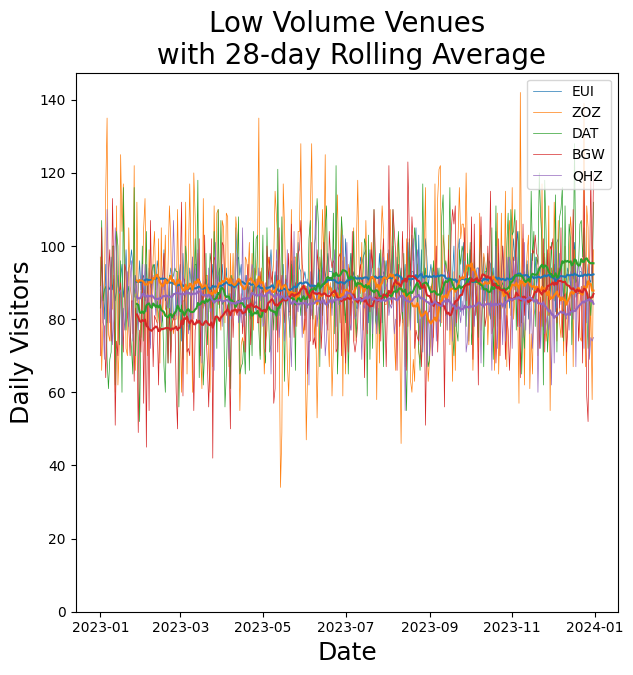

In [ ]:
period = 28
rolling_average = data.rolling(window=period).mean()

selected = ['EUI', 'ZOZ', 'DAT', 'BGW', 'QHZ']
print(data[selected].head())

plt.figure(figsize=(7, 7))
plt.plot(data[selected], linewidth=0.5)

plt.gca().set_prop_cycle(None)
plt.plot(rolling_average[selected], linewidth=1.5)
plt.ylim(ymin=0)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Daily Visitors', fontsize=18)
plt.title('Low Volume Venues\n with 28-day Rolling Average', fontsize=20)
plt.legend(selected, loc=1)
plt.show()

            AUT  QNM  RTE  AOJ  CUB  RBO  DGG  ZGP  COQ  BAL  VUV  SZY  TNB  \
Date                                                                          
2023-01-01   82   70   77   79   87   49   48   70   56   72    0   96    0   
2023-01-02   90   78   64   78   53   59   72   58   68   66    0   92    0   
2023-01-03   77   92   70   70   59   56   67   49   69   60    0   91    0   
2023-01-04   84   84   84   83   54   74   65   74   59   63    0   92    0   
2023-01-05   73   85   85   84   87   72   61   59   58   65    0   88    0   

            TTL  RNT  SHI  UHQ  UAF  
Date                                 
2023-01-01   66    0    0    0    0  
2023-01-02   54    0    0    0    0  
2023-01-03   63    0    0    0    0  
2023-01-04   88    0    0    0    0  
2023-01-05   54    0    0    0    0  


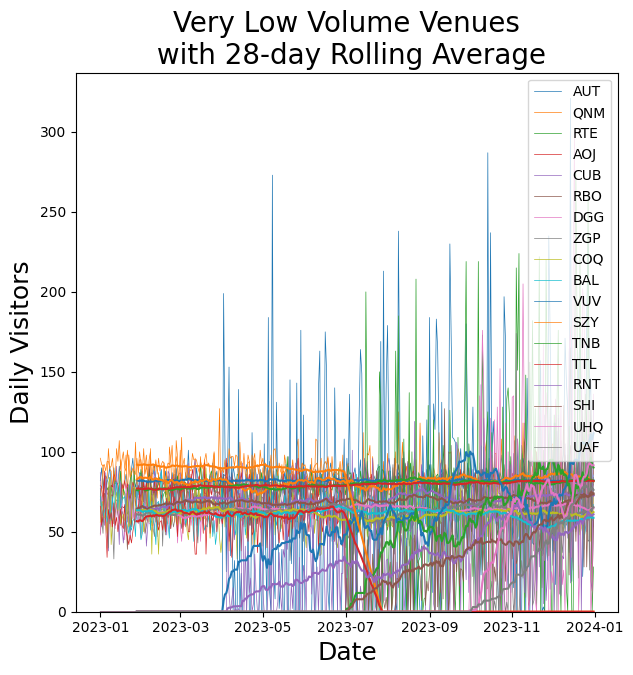

In [ ]:
period = 28
rolling_average = data.rolling(window=period).mean()

selected = ['AUT', 'QNM', 'RTE', 'AOJ', 'CUB', 'RBO', 'DGG', 'ZGP', 'COQ', 'BAL', 'VUV', 'SZY', 'TNB', 'TTL', 'RNT', 'SHI', 'UHQ', 'UAF']
print(data[selected].head())

plt.figure(figsize=(7, 7))
plt.plot(data[selected], linewidth=0.5)

plt.gca().set_prop_cycle(None)
plt.plot(rolling_average[selected], linewidth=1.5)
plt.ylim(ymin=0)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Daily Visitors', fontsize=18)
plt.title('Very Low Volume Venues\n with 28-day Rolling Average', fontsize=20)
plt.legend(selected, loc=1)
plt.show()

#Box Plot of High Volume Venues Daily Visitors

/tmp/ipython-input-1709359821.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data[selected], labels=selected)


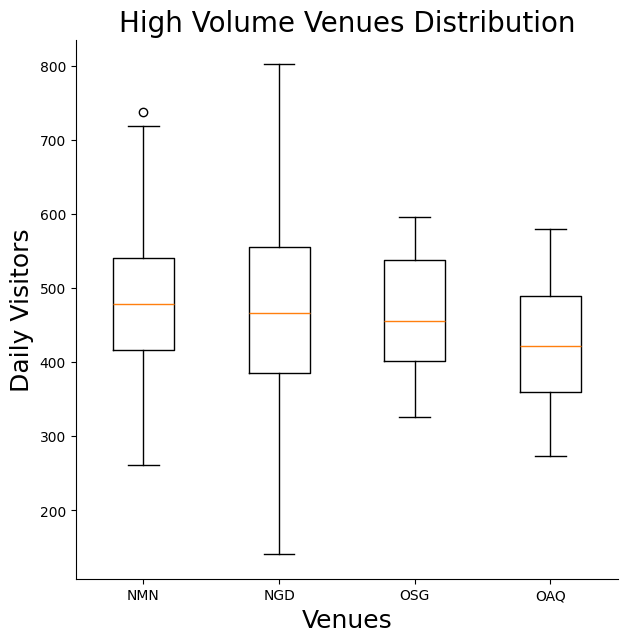

In [ ]:
selected = ['NMN', 'NGD', 'OSG', 'OAQ']

plt.figure(figsize=(7, 7))
# data[selected].boxplot()
plt.boxplot(data[selected], labels=selected)
plt.xlabel('Venues', fontsize=18)
plt.ylabel('Daily Visitors', fontsize=18)
plt.title('High Volume Venues Distribution', fontsize=20)

for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
  if spine.spine_type != 'bottom' and spine.spine_type != 'left':
    spine.set_visible(False)

plt.show()

* Outlier with venue NMN (most visited).

*   NGD has the largest distribution.
*   OSG and OAQ have similar distributions.





#Interactive heatmap of all venues


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
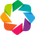

:HeatMap   [columns,index]   (value)

In [ ]:
data = pd.read_csv('https://tinyurl.com/ChrisCoDV/001357669/VenueDailyVisitors.csv', index_col=0)
data.index = pd.to_datetime(data.index)

plot = data.corr().hvplot.heatmap(
    frame_height=500, frame_width=500,
    title='Venues correlations',
    rot=90, cmap='coolwarm'  # see http://holoviews.org/user_guide/Colormaps.html
).opts(invert_yaxis=True, clim=(-1, 1))
hv.extension('bokeh')
plot

The highest correlations are between the lower volume venues, therefore, I do not feel the need to include this visualisation.

#**Summary Data Visualisation**

#Radar Plot of High Volume Visited Venues

In [ ]:
normalised_data = summary_data / summary_data.max()
print(normalised_data.head())

     Average Duration  Annual Visitors  Average Spend  Average Age  Female %  \
DAT          0.686667         0.183944       0.709677     0.527273  0.700000   
ZOZ          0.720000         0.184958       0.774194     0.872727  0.800000   
TNB          0.660000         0.068977       0.419355     0.654545  0.900000   
MAJ          0.520000         0.428809       0.677419     0.836364  0.883333   
CUB          1.000000         0.145373       0.387097     0.509091  0.983333   

     Maximum Distance  
DAT          0.181818  
ZOZ          0.142857  
TNB          0.025974  
MAJ          0.194805  
CUB          0.077922  


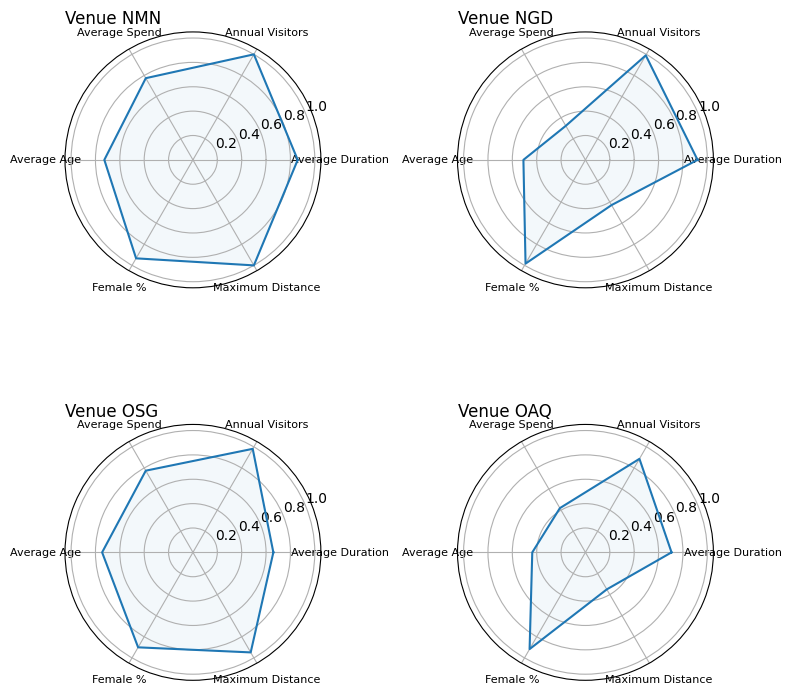

In [ ]:
selected = ['NMN', 'NGD', 'OSG', 'OAQ']


n_attributes = len(normalised_data.columns)
angles = [n / float(n_attributes) * 2 * np.pi for n in range(n_attributes + 1)]
plt.figure(figsize=(8, 8))
counter = 1
for name in selected:
    values = normalised_data.loc[[name]].values.flatten().tolist()
    values += values[:1]
    sub = plt.subplot(2, 2, counter, polar=True)
    sub.plot(angles, values)
    sub.fill(angles, values, alpha=0.05)
    sub.set_ylim(ymax=1.05)
    sub.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    sub.set_xticks(angles[0:-1])
    sub.set_xticklabels(normalised_data.columns, fontsize=8)
    #need to order them from the beginning
    sub.set_title('Venue ' + name, fontsize=12, loc='left')
    counter += 1
plt.tight_layout()
plt.show()

Venue NMN and OSG match in shape. Have a higher average spend, average age and maximum distance.
Venue NGD and OAQ match in shape. Have a lower average spend, average age and maximum distance compared to the other two.

#Correlelogram of High Volume Visited Venues

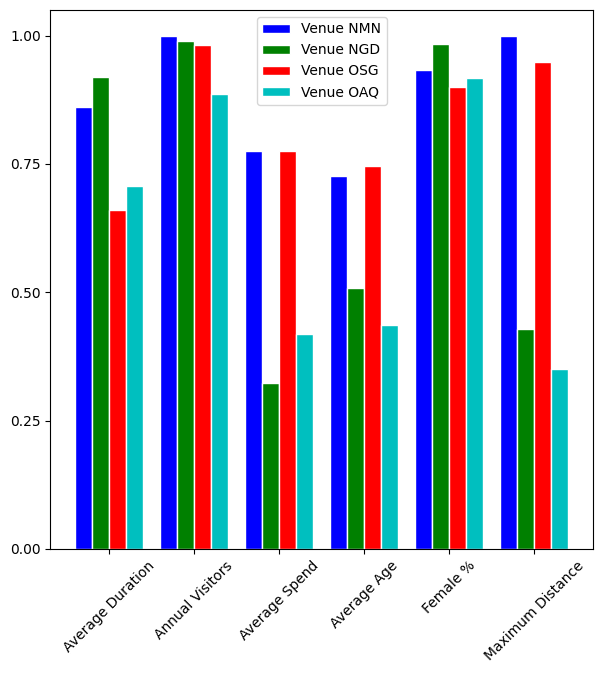

In [ ]:
colours = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
plt.figure(figsize=(7, 7))
c = 0
n_bars = len(selected)
x_pos_base = np.arange(len(summary_data.columns))
bar_width = 0.8 / n_bars
for name in selected:
    values = normalised_data.loc[[name]].values.flatten().tolist()
    x_pos = [x + (bar_width * c) for x in x_pos_base]
    plt.bar(x_pos, values, color=colours[c % len(colours)],
            width=bar_width, edgecolor='white', label='Venue ' + name)
    c += 1
plt.yticks([0, 0.25, 0.5, 0.75, 1])
x_pos = [x + (bar_width * (c - 1) / 2) for x in x_pos_base]
plt.xticks(x_pos, summary_data.columns, rotation=45)
plt.legend()
plt.show()

#Pair plot of summary data

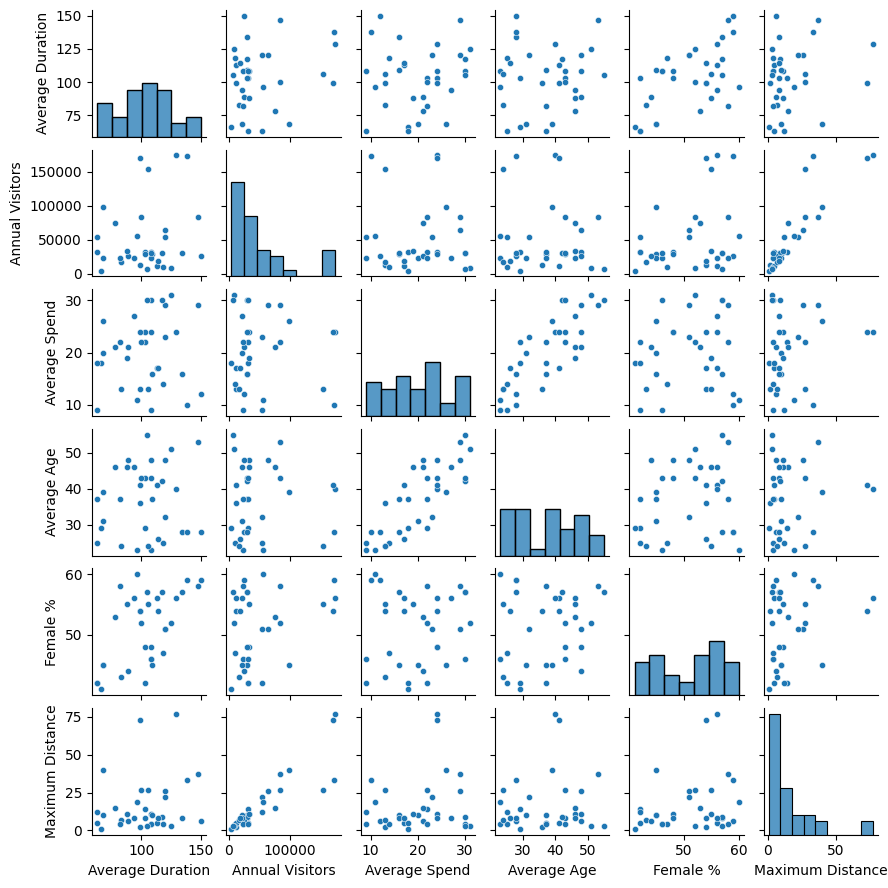

In [ ]:
sns.pairplot(summary_data, height=1.5, plot_kws={'s': 20})
plt.show()

#Heatmap of summary data

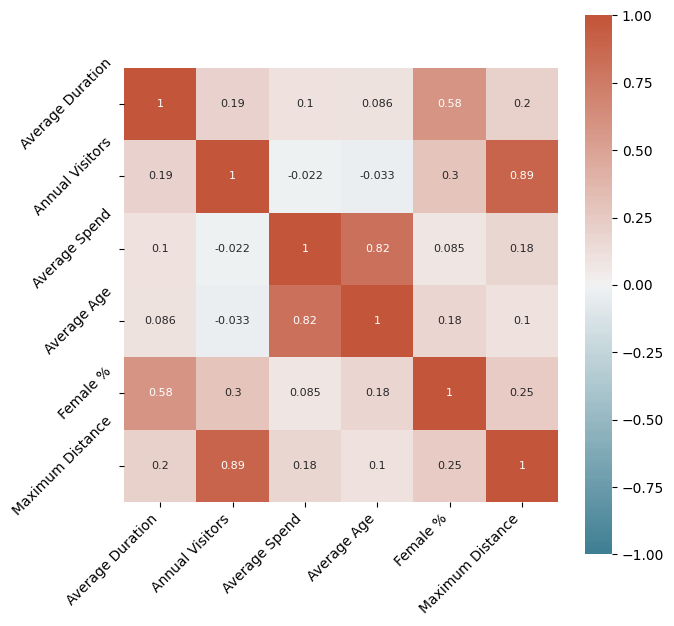

In [ ]:
plt.figure(figsize=(7, 7))
corr = summary_data.corr()
ax = sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap=sns.diverging_palette(220, 20, n=200), square=True, annot=True,
                 annot_kws={"size": 8})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, horizontalalignment='right')
plt.show()

High positive correlation:

Annual visitors and Maximum venue distance - 0.89

Average age and Average spend - 0.82



In [ ]:
summary_data

,Average Duration,Annual Visitors,Average Spend,Average Age,Female %,Maximum Distance
DAT,103,32105,22,29,42,14
ZOZ,108,32282,24,48,48,11
TNB,99,12039,13,36,54,2
MAJ,78,74843,21,46,53,15
CUB,150,25373,12,28,59,6
RNT,118,10123,14,25,47,4
AOJ,103,29013,24,43,48,8
UAF,66,4366,18,29,41,1
RTE,109,29058,16,37,45,10
VIY,120,63873,29,48,51,26


#Bubble Plot of summary data

In [ ]:
summary_data['BubbleSize'] = summary_data['Annual Visitors'] * 0.04


plot = summary_data.hvplot.scatter(
    frame_height=500, frame_width=500,
    title='Average Age vs Average Spend (vs Annual Visitors)',
    xlabel='Average Age', ylabel='Average Spend (£)',
    alpha=0.5, padding=0.1, hover_cols='all',
    tools=['undo', 'redo'],
    x='Average Age', y='Average Spend', size='BubbleSize'
)
plot

:Scatter   [Average Age]   (Average Spend,BubbleSize,index,Average Duration,Annual Visitors,Female %,Maximum Distance)

I chose the bubble plot of average age, spend and annual visitors as the two former have a high positive correlation seen in the correlation heatmap above. Since those two have a high correlation, it was suitable to show this in the x axis and y axis. Annual visitors was added as the bubble size because this data would be more important to the business, in addition, I have been exploring this data throughout the visualisations so it continues the narrative.

The highest average spend is £31 from venue SHI (a very low volume venue) with an average age of 51.